# Chunk-based Change Score for Risk Disclosures (t vs t-1)

このノートブックは、前年との差分を「全文1本」ではなく **チャンク単位**で捉えることで、
「項目が1つ増えた」などの変化を拾いやすくする手法を実装します。

## コアアイデア（推奨）
- 当年のチャンク集合 \(C_t\)、前年のチャンク集合 \(C_{t-1}\) を作る
- 当年チャンクごとに前年チャンクとの最大類似度を取る

\[
\text{sim}_i = \max_{j \in C_{t-1}} \cos(e_{i,t}, e_{j,t-1}),\qquad
\text{change}_i = 1 - \text{sim}_i
\]

- 文書（会社×年度）スコアへ集約
  - **change_mean**: 平均
  - **change_topk**: 上位k平均（新規項目が少数でも効く）
  - **change_ratio**: \(\text{sim}_i < \tau\) の比率

## 出力
- `risk_change_scores` テーブルに保存
- 統制用に `text_len_*` と `num_chunks_*` も保存


In [2]:
import os
import re
import unicodedata
from dataclasses import dataclass

import numpy as np
import pandas as pd
import torch
from dotenv import load_dotenv
from sqlalchemy import create_engine, text
from tqdm.auto import tqdm

from sentence_transformers import SentenceTransformer

tqdm.pandas()


In [3]:
def find_project_root(start_dir: str) -> str:
    d = os.path.abspath(start_dir)
    while True:
        if os.path.exists(os.path.join(d, "docker-compose.yml")) and os.path.exists(os.path.join(d, "requirements.txt")):
            return d
        parent = os.path.dirname(d)
        if parent == d:
            return os.path.abspath(start_dir)
        d = parent

PROJECT_ROOT = find_project_root(os.getcwd())
os.chdir(PROJECT_ROOT)
print("PROJECT_ROOT:", PROJECT_ROOT)

load_dotenv(dotenv_path=os.path.join(PROJECT_ROOT, ".env"))

DB_USER = os.getenv("POSTGRES_USER")
DB_PASS = os.getenv("POSTGRES_PASSWORD")
DB_HOST = os.getenv("POSTGRES_HOST", "localhost")
DB_PORT = os.getenv("POSTGRES_PORT", "5432")
DB_NAME = os.getenv("POSTGRES_DB")

db_url = f"postgresql+psycopg2://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
engine = create_engine(db_url)
print("Connected.")


PROJECT_ROOT: /home/junxzi/dev/risk-novelty-stock-jp
Connected.


In [ ]:
HEADER_PATTERNS = [
    r"【.*?】",
    r"^\s*[０-９0-9]+\s*",
    r"^\s*第[０-９0-9]+",
]

BOILERPLATE_PATTERNS = [
    r"有価証券報告書に記載した.*?認識している主要なリスクは、以下のとおり.*?。",
    r"なお、文中の将来に関する事項は.*?判断したものであります。",
    r"文中の将来に関する事項は.*?判断したものであります。",
    r"当社グループは、これらのリスクを認識したうえで.*?努めてまいります。",
    r"詳細については、.*?をご参照ください。",
]

def normalize_text(s: str) -> str:
    if s is None:
        return ""
    s = str(s)

    # A) header cleanup line-by-line
    lines = []
    for line in s.splitlines():
        t = line
        for p in HEADER_PATTERNS:
            t = re.sub(p, "", t)
        t = t.strip()
        if t:
            lines.append(t)
    s = "\n".join(lines)

    # B) unicode normalize
    s = unicodedata.normalize("NFKC", s)

    # C) boilerplate remove
    for p in BOILERPLATE_PATTERNS:
        s = re.sub(p, "", s, flags=re.DOTALL)

    # D) whitespace normalize
    s = re.sub(r"[ \t\u3000]+", " ", s)
    s = re.sub(r"\n{2,}", "\n", s)
    s = s.strip()

    # E) numeric masks (order matters)
    s = re.sub(r"\d{1,3}(,\d{3})+\s*円", "<MONEY>", s)
    s = re.sub(r"\d+(\.\d+)?\s*%", "<PCT>", s)
    s = re.sub(r"(19|20)\d{2}年", "<YEAR>", s)
    s = re.sub(r"(19|20)\d{2}", "<YEAR>", s)
    s = re.sub(r"\d+(\.\d+)?", "<NUM>", s)

    # F) light entity masks
    s = s.replace("当社グループ", "<COMPANY>")
    s = s.replace("当社", "<COMPANY>")

    # G) light modality normalization (do NOT delete)
    s = s.replace("可能性があります", "<MODAL>")
    s = s.replace("おそれがあります", "<MODAL>")
    s = s.replace("恐れがあります", "<MODAL>")
    s = s.replace("と考えております", "<THINK>")

    # H) final normalize
    s = re.sub(r"\s+", " ", s).strip()
    return s


In [5]:
BULLET_SPLIT_RE = re.compile(
    r"(?:\n|^)(?:[・●]|\(?[0-9]+\)?|[①②③④⑤⑥⑦⑧⑨⑩]|[a-zA-Z]\)|\([ivxIVX]+\))\s*"
)

def chunk_text(text: str, min_len: int = 30, target_min: int = 100, target_max: int = 500) -> list[str]:
    if not text:
        return []

    # 1) split by newline
    parts = [p.strip() for p in text.split("\n") if p.strip()]

    # 2) split bullet-like
    finer: list[str] = []
    for p in parts:
        x = BULLET_SPLIT_RE.sub("\n", p)
        finer.extend([q.strip() for q in x.split("\n") if q.strip()])

    # 3) if too long, split by 。 and regroup
    chunks: list[str] = []
    for p in finer:
        if len(p) <= target_max:
            chunks.append(p)
            continue

        sents = [s.strip() for s in p.split("。") if s.strip()]
        buf: list[str] = []
        for s in sents:
            buf.append(s + "。")
            if len(buf) >= 3:  # 2〜4文の塊を意識
                chunks.append("".join(buf).strip())
                buf = []
        if buf:
            chunks.append("".join(buf).strip())

    # 4) merge very short
    merged: list[str] = []
    for c in chunks:
        if not merged:
            merged.append(c)
            continue
        if len(c) < min_len:
            merged[-1] = (merged[-1] + " " + c).strip()
        else:
            merged.append(c)

    # 5) ensure min chunk size
    final: list[str] = []
    for c in merged:
        if not final:
            final.append(c)
            continue
        if len(c) < target_min:
            final[-1] = (final[-1] + " " + c).strip()
        else:
            final.append(c)

    return [c for c in final if c.strip()]

# quick sanity
sample = "(1) AAA\n・BBB。CCC。DDD。\n(2) EEE"
print(chunk_text(sample))


['AAA BBB。CCC。DDD。 EEE']


In [ ]:
sql = """
SELECT doc_id, company_id, fiscal_year, risk_text
FROM edinet_documents
WHERE risk_text IS NOT NULL AND risk_text != '';
"""

df = pd.read_sql(sql, engine)
df['risk_text_norm'] = df['risk_text'].map(normalize_text)
df['prev_year'] = df['fiscal_year'] - 1

# pairs: (t) joined with (t-1)
df_pairs = pd.merge(
    df,
    df[['company_id', 'fiscal_year', 'doc_id', 'risk_text_norm']],
    left_on=['company_id', 'prev_year'],
    right_on=['company_id', 'fiscal_year'],
    suffixes=('_curr', '_prev'),
    how='inner'
)

df_pairs = df_pairs[[
    'company_id',
    'fiscal_year_curr',
    'doc_id_curr',
    'doc_id_prev',
    'risk_text_norm_curr',
    'risk_text_norm_prev'
]]

print('pairs:', len(df_pairs))
df_pairs.head()


pairs (after sampling): 80


,company_id,fiscal_year,doc_id_curr,doc_id_prev,risk_text_norm_curr,risk_text_norm_prev
6442,be377664-129e-4752-9f94-a26b7d4efe28,2023,S100R1IZ,S100ODPW,ほくでんグループの業績に影響を及ぼす可能性のある主なリスクには以下のようなものがある。なお、...,ほくでんグループの業績に影響を及ぼす可能性のある主なリスクには以下のようなものがある。なお、...
5553,adecbfd9-481f-4a13-a662-3fc162a55c89,2024,S100TQ3L,S100R1XD,<COMPANY>はグループ理念「食を通じて人とつながり、笑顔ある暮らしを共につくるグッドパ...,<COMPANY>はグループ理念「食を通じて人とつながり、笑顔ある暮らしを共につくるグッドパ...
457,eba75e57-40e8-4fab-a89a-ebff3e4bab5a,2025,S100VIKQ,S100T3KX,<<COMPANY>の経営リスク管理体制について><COMPANY>は、企業が将来生み出す収...,<COMPANY>は、企業が将来生み出す収益に対して影響を与えると考えられる、発生が不確定の...
5070,7a284887-8d57-4023-9ea5-9c5359ab14db,2021,S100LJIS,S100ISUJ,<COMPANY>は、グループ全体におけるリスクの把握と発生の防止に努め、チャンス(機会)を...,<COMPANY>は、グループ全体におけるリスクの把握と発生の防止に努め、チャンス(機会)を...
2722,602f7941-6045-4f05-91d5-ec4b57cc3c52,2022,S100ODMQ,S100LN4K,<COMPANY>は、マクロの環境変化や、影響の大きさ(大・中・小)、発現の蓋然性や時期(高...,<COMPANY>の経営成績及び財務状況等に影響を及ぼす可能性のあるリスクには、重要項目ごと...


In [ ]:
@dataclass
class ScoreParams:
    tau: float = 0.85
    topk_min: int = 1
    topk_max: int = 3
    topk_frac: float = 0.10

params = ScoreParams(tau=0.85)

model_name = os.getenv('RISK_EMBED_MODEL', 'intfloat/multilingual-e5-small')
print('Embedding model:', model_name)
model = SentenceTransformer(model_name)

def encode_chunks(chunks: list[str]) -> torch.Tensor:
    if not chunks:
        return torch.empty((0, 1))

    # E5系は prefix 推奨
    if model_name.startswith('intfloat/') and 'e5' in model_name:
        chunks = ['query: ' + c for c in chunks]

    emb = model.encode(
        chunks,
        convert_to_tensor=True,
        normalize_embeddings=True,
        show_progress_bar=False,
        batch_size=32,
    )
    return emb

def compute_change_scores(text_curr: str, text_prev: str, params: ScoreParams):
    chunks_curr = chunk_text(text_curr)
    chunks_prev = chunk_text(text_prev)

    n = len(chunks_curr)
    m = len(chunks_prev)

    text_len_curr = len(text_curr)
    text_len_prev = len(text_prev)

    if n == 0:
        return {
            'change_mean': np.nan,
            'change_topk': np.nan,
            'change_ratio': np.nan,
            'topk_k': 0,
            'num_chunks_curr': 0,
            'num_chunks_prev': m,
            'text_len_curr': text_len_curr,
            'text_len_prev': text_len_prev,
        }

    if m == 0:
        change = np.ones(n)
    else:
        emb_curr = encode_chunks(chunks_curr)
        emb_prev = encode_chunks(chunks_prev)

        sims = (emb_curr @ emb_prev.T).cpu().numpy()  # (n, m)
        max_sim = sims.max(axis=1)
        change = 1.0 - max_sim

    change_mean = float(np.mean(change))

    k = int(round(params.topk_frac * n))
    k = max(params.topk_min, min(params.topk_max, k))
    change_topk = float(np.mean(np.sort(change)[-k:]))

    # sim_i < tau  <=>  change_i > 1-tau
    change_ratio = float(np.mean(change > (1.0 - params.tau)))

    return {
        'change_mean': change_mean,
        'change_topk': change_topk,
        'change_ratio': change_ratio,
        'topk_k': k,
        'num_chunks_curr': n,
        'num_chunks_prev': m,
        'text_len_curr': text_len_curr,
        'text_len_prev': text_len_prev,
    }


Embedding model: pkshatech/GLuCoSE-base-ja


sentencepiece.bpe.model:   0%|          | 0.00/842k [00:00<?, ?B/s]

entity_vocab.json:   0%|          | 0.00/62.0 [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/40.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/595 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
records = []
for row in tqdm(df_pairs.itertuples(index=False), total=len(df_pairs), desc='Scoring'):
    s = compute_change_scores(row.risk_text_norm_curr, row.risk_text_norm_prev, params)
    records.append({
        'company_id': row.company_id,
        'fiscal_year': int(row.fiscal_year_curr),
        'doc_id_curr': row.doc_id_curr,
        'doc_id_prev': row.doc_id_prev,
        'change_mean': s['change_mean'],
        'change_topk': s['change_topk'],
        'change_ratio': s['change_ratio'],
        'tau': params.tau,
        'topk_k': s['topk_k'],
        'num_chunks_curr': s['num_chunks_curr'],
        'num_chunks_prev': s['num_chunks_prev'],
        'text_len_curr': s['text_len_curr'],
        'text_len_prev': s['text_len_prev'],
    })

df_scores = pd.DataFrame(records)
df_scores[['change_mean','change_topk','change_ratio','num_chunks_curr','text_len_curr']].describe()


Scoring:   0%|          | 0/80 [00:00<?, ?it/s]

,change_mean,change_topk,change_ratio,max_sim_min,max_sim_p10,max_sim_median,num_chunks_curr,text_len_curr
count,8.000000e+01,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000
mean,7.542168e-02,0.188341,0.470978,0.794864,0.858515,0.936189,20.325000,6358.537500
std,7.906131e-02,0.134912,0.367063,0.144056,0.116847,0.086487,16.640484,5384.504528
min,-2.980232e-08,0.000000,0.000000,0.361862,0.373439,0.542395,1.000000,1147.000000
25%,1.302938e-02,0.096234,0.094156,0.725070,0.803956,0.901622,9.000000,2568.750000
50%,6.316825e-02,0.195586,0.456265,0.794957,0.849271,0.981066,16.000000,5040.500000
75%,1.052000e-01,0.253733,0.818182,0.890197,0.986622,1.000000,25.000000,8027.500000
max,4.177732e-01,0.638138,1.000000,1.000000,1.000000,1.000000,77.000000,28637.000000


In [ ]:
from sqlalchemy.dialects.postgresql import UUID

# Save to DB only when running full data
if SAMPLE_MODE:
    print('SAMPLE_MODE=True -> skip saving to DB')
else:
    ddl = """
    CREATE TABLE IF NOT EXISTS risk_change_scores (
        company_id UUID NOT NULL,
        fiscal_year INT NOT NULL,
        doc_id_curr VARCHAR(20),
        doc_id_prev VARCHAR(20),
        change_mean DOUBLE PRECISION,
        change_topk DOUBLE PRECISION,
        change_ratio DOUBLE PRECISION,
        tau DOUBLE PRECISION,
        topk_k INT,
        num_chunks_curr INT,
        num_chunks_prev INT,
        text_len_curr INT,
        text_len_prev INT,
        max_sim_min DOUBLE PRECISION,
        max_sim_p10 DOUBLE PRECISION,
        max_sim_median DOUBLE PRECISION,
        updated_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
        PRIMARY KEY (company_id, fiscal_year)
    );
    """

    with engine.begin() as conn:
        conn.execute(text(ddl))

    # Use dtype to keep company_id as UUID in DB
    df_scores.to_sql(
        'risk_change_scores',
        engine,
        if_exists='replace',
        index=False,
        method='multi',
        chunksize=1000,
        dtype={'company_id': UUID(as_uuid=True)}
    )
    print('Saved:', len(df_scores))


Saved: 7345


## 6) Quick sanity: price reaction around submit date (sample)

全件実行の前に、サンプル上で **change_topk とイベント前後のリターン** がざっくり連動しそうか確認します。

- Event date: `edinet_documents.submit_date`
- Rule of thumb: 提出時刻が15:00以降なら、反応は翌営業日に出やすいので **イベント日を次の取引日** に寄せます。
- Return metric (simple): `CAR[-1,+1] = P(t+1)/P(t-1) - 1`（市場調整なしの簡易版）


In [9]:
import matplotlib.pyplot as plt

# 1) attach submit_date and security_code
q_meta = """
SELECT d.doc_id, d.submit_date, c.security_code
FROM edinet_documents d
JOIN companies c ON c.company_id = d.company_id
WHERE d.doc_id = ANY(:doc_ids);
"""

doc_ids = df_scores['doc_id_curr'].dropna().unique().tolist()
meta = pd.read_sql(text(q_meta), engine, params={'doc_ids': doc_ids})
meta['event_ts'] = pd.to_datetime(meta['submit_date'])
meta['event_date'] = meta['event_ts'].dt.date

sample = df_scores.merge(meta[['doc_id','security_code','event_ts','event_date']], left_on='doc_id_curr', right_on='doc_id', how='left')
print('sample rows with meta:', sample['security_code'].notna().mean())
sample.head()


sample rows with meta: 1.0


,company_id,fiscal_year,doc_id_curr,doc_id_prev,change_mean,change_topk,change_ratio,tau,topk_k,num_chunks_curr,num_chunks_prev,text_len_curr,text_len_prev,max_sim_min,max_sim_p10,max_sim_median,doc_id,security_code,event_ts,event_date
0,be377664-129e-4752-9f94-a26b7d4efe28,2023,S100R1IZ,S100ODPW,0.064782,0.188691,0.444444,0.97,1,9,9,2547,2588,0.811309,0.839325,0.978590,S100R1IZ,95090,2023-06-29 09:34:00,2023-06-29
1,adecbfd9-481f-4a13-a662-3fc162a55c89,2024,S100TQ3L,S100R1XD,0.044348,0.199767,0.352941,0.97,2,17,16,7432,6762,0.757943,0.860374,0.993972,S100TQ3L,28100,2024-06-25 14:19:00,2024-06-25
2,eba75e57-40e8-4fab-a89a-ebff3e4bab5a,2025,S100VIKQ,S100T3KX,0.147881,0.321377,0.892857,0.97,3,56,44,14553,11159,0.619257,0.753617,0.846066,S100VIKQ,49670,2025-03-28 15:32:00,2025-03-28
3,7a284887-8d57-4023-9ea5-9c5359ab14db,2021,S100LJIS,S100ISUJ,0.066718,0.112381,0.714286,0.97,1,7,8,2173,2287,0.887619,0.898431,0.914999,S100LJIS,79660,2021-06-21 14:13:00,2021-06-21
4,602f7941-6045-4f05-91d5-ec4b57cc3c52,2022,S100ODMQ,S100LN4K,0.417773,0.638138,1.000000,0.97,1,4,1,6172,483,0.361862,0.373439,0.542395,S100ODMQ,28020,2022-06-23 13:25:00,2022-06-23


In [13]:
# 2) fetch price data around event for sample codes
codes = sample['security_code'].dropna().astype(str).unique().tolist()

# fetch a wide window to be safe
min_date = pd.to_datetime(sample['event_date'].min()) - pd.Timedelta(days=14)
max_date = pd.to_datetime(sample['event_date'].max()) + pd.Timedelta(days=14)

q_quotes = """
SELECT code, date, adjusted_close
FROM daily_quotes
WHERE code = ANY(:codes)
  AND date BETWEEN :d0 AND :d1
ORDER BY code, date;
"""

quotes = pd.read_sql(text(q_quotes), engine, params={
    'codes': codes,
    'd0': min_date.date(),
    'd1': max_date.date(),
})
quotes['date'] = pd.to_datetime(quotes['date'])
quotes['adjusted_close'] = pd.to_numeric(quotes['adjusted_close'], errors='coerce')

# build dict: code -> sorted dates
by_code = {c: g.dropna(subset=['adjusted_close']).sort_values('date').reset_index(drop=True) for c,g in quotes.groupby('code')}
print('codes fetched:', len(by_code))


codes fetched: 76


In [14]:
def next_trading_day(code: str, dt: pd.Timestamp) -> pd.Timestamp | None:
    g = by_code.get(code)
    if g is None or g.empty:
        return None
    # first date >= dt
    idx = g['date'].searchsorted(dt, side='left')
    if idx >= len(g):
        return None
    return g.loc[idx, 'date']

def shift_trading_day(code: str, dt: pd.Timestamp, k: int) -> pd.Timestamp | None:
    g = by_code.get(code)
    if g is None or g.empty:
        return None
    idx = g['date'].searchsorted(dt, side='left')
    if idx >= len(g):
        return None
    idx2 = idx + k
    if idx2 < 0 or idx2 >= len(g):
        return None
    return g.loc[idx2, 'date']

def price_on(code: str, dt: pd.Timestamp) -> float | None:
    g = by_code.get(code)
    if g is None or g.empty:
        return None
    # exact match
    m = g[g['date'] == dt]
    if m.empty:
        return None
    return float(m['adjusted_close'].iloc[0])

def car_simple(code: str, submit_ts: pd.Timestamp, window=(-1, 1), cutoff_hour=15) -> float | None:
    if pd.isna(submit_ts):
        return None
    # event day: if submit after cutoff, use next trading day
    base = pd.Timestamp(submit_ts.date())
    event_day = next_trading_day(code, base)
    if event_day is None:
        return None
    if submit_ts.hour >= cutoff_hour:
        event_day = shift_trading_day(code, event_day, 1)
        if event_day is None:
            return None

    start_day = shift_trading_day(code, event_day, window[0])
    end_day = shift_trading_day(code, event_day, window[1])
    if start_day is None or end_day is None:
        return None

    p0 = price_on(code, start_day)
    p1 = price_on(code, end_day)
    if p0 is None or p1 is None or p0 <= 0:
        return None
    return (p1 / p0) - 1

sample['car_m1_p1'] = sample.apply(lambda r: car_simple(str(r['security_code']), pd.to_datetime(r['event_ts']), window=(-1,1)), axis=1)
print(sample['car_m1_p1'].describe())


count    79.000000
mean     -0.003139
std       0.034154
min      -0.161727
25%      -0.020525
50%      -0.003922
75%       0.014419
max       0.079842
Name: car_m1_p1, dtype: float64


usable rows: 79
corr(change_topk, CAR[-1,+1]) = 0.24101026333896697


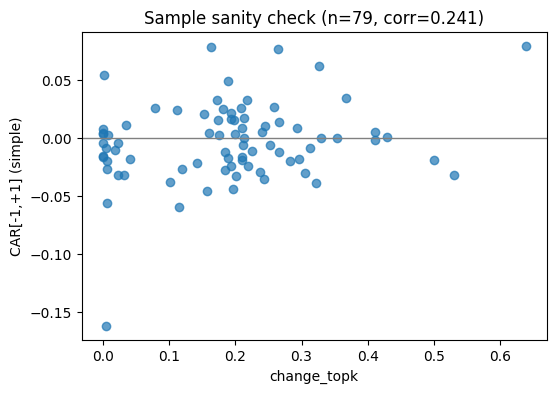

In [15]:
# 3) quick correlation / scatter
sub = sample.dropna(subset=['change_topk','car_m1_p1']).copy()
print('usable rows:', len(sub))

corr = sub[['change_topk','car_m1_p1']].corr().iloc[0,1]
print('corr(change_topk, CAR[-1,+1]) =', corr)

plt.figure(figsize=(6,4))
plt.scatter(sub['change_topk'], sub['car_m1_p1'], alpha=0.7)
plt.axhline(0, color='gray', linewidth=1)
plt.xlabel('change_topk')
plt.ylabel('CAR[-1,+1] (simple)')
plt.title(f'Sample sanity check (n={len(sub)}, corr={corr:.3f})')
plt.show()


## 7) Compare multiple windows (sample)

`(-1,+1)` だけでなく、いくつかのイベント窓で相関を確認します。

- `CAR[-3,+3]`
- `CAR[0,+1]`

**注意**: これは市場調整なしの“簡易”イベントリターンです。

- 本番のイベントスタディでは、TOPIX等で市場調整（市場モデル/マーケット調整）や推定期間を入れます。
- ただ、今は「スコアが株価と全く無関係に見えるか？」の早期検知が目的なので、まずこの形でOKです。


In [17]:
# additional windows
sample['car_m3_p3'] = sample.apply(
    lambda r: car_simple(str(r['security_code']), pd.to_datetime(r['event_ts']), window=(-3, 3)),
    axis=1
)

sample['car_0_p1'] = sample.apply(
    lambda r: car_simple(str(r['security_code']), pd.to_datetime(r['event_ts']), window=(0, 1)),
    axis=1
)

for col, label in [
    ('car_m1_p1', 'CAR[-1,+1]'),
    ('car_m3_p3', 'CAR[-3,+3]'),
    ('car_0_p1',  'CAR[0,+1]'),
]:
    sub = sample.dropna(subset=['change_topk', col]).copy()
    corr = sub[['change_topk', col]].corr().iloc[0, 1]
    print(label, 'n=', len(sub), 'corr=', corr)


CAR[-1,+1] n= 79 corr= 0.24101026333896697
CAR[-3,+3] n= 77 corr= 0.139081143790925
CAR[0,+1] n= 79 corr= 0.1860045009760639
